<a href="https://colab.research.google.com/github/ivangacha89/Proyecto-Sistema-de-Analisis-Comercial-con-Python/blob/main/Proyecto_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final — Sistema de Análisis Comercial con Python

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Limpieza

### Archivo 06_metas

In [2]:
# Carga del archivo 06_metas_xlsx
df_metas = pd.read_excel('/content/sample_data/06_metas.xlsx')
df_metas

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades
0,SUC-001,2024-01-01 00:00:00,6774353,38
1,SUC-001,2024-02-01 00:00:00,3579350,14
2,SUC-001,2024-03-01 00:00:00,5412798,23
3,SUC-001,2024-04-01 00:00:00,2460269,7
4,SUC-001,2024-05-01 00:00:00,3550319,10
...,...,...,...,...
189,SUC-012,2025-02-01 00:00:00,7414426,46
190,SUC-012,NaN,25701586,89
191,SUC-012,2025-04-01 00:00:00,198983089,74
192,SUC-001,2024-01-01 00:00:00,6774353,38


In [3]:
# Cantidad de filas y columnas
df_metas.shape

(194, 4)

In [4]:
# Tipos de datos por columna
df_metas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   SucursalID     194 non-null    object
 1   Fecha          191 non-null    object
 2   Meta_Ventas    192 non-null    object
 3   Meta_Unidades  190 non-null    object
dtypes: object(4)
memory usage: 6.2+ KB


In [5]:
# Exploracion de datos reales
df_metas.head(10)

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades
0,SUC-001,2024-01-01 00:00:00,6774353,38
1,SUC-001,2024-02-01 00:00:00,3579350,14
2,SUC-001,2024-03-01 00:00:00,5412798,23
3,SUC-001,2024-04-01 00:00:00,2460269,7
4,SUC-001,2024-05-01 00:00:00,3550319,10
5,SUC-001,2024-06-01 00:00:00,5612664,29
6,SUC-001,2024-07-01 00:00:00,3636956,13
7,SUC-001,2024-08-01 00:00:00,777559,6
8,SUC-001,2024-09-01 00:00:00,76183198,17
9,SUC-001,fecha error,4276721,14


In [6]:
# Cantidad de filas 100% repetidas
df_metas.duplicated().sum()

np.int64(2)

In [7]:
# Cantidad de valores vacios por columna
df_metas.isnull().sum()

,0
SucursalID,0
Fecha,3
Meta_Ventas,2
Meta_Unidades,4


In [8]:
# Copia de la informacion original
df_metas_original = df_metas.copy()

In [9]:
# Eliminar duplicados y confirmar el conteo de filas y columnas
df_metas = df_metas.drop_duplicates()
df_metas.shape

(192, 4)

In [10]:
# Reset del index tras la eliminacion de filas
df_metas = df_metas.reset_index(drop=True)
df_metas

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades
0,SUC-001,2024-01-01 00:00:00,6774353,38
1,SUC-001,2024-02-01 00:00:00,3579350,14
2,SUC-001,2024-03-01 00:00:00,5412798,23
3,SUC-001,2024-04-01 00:00:00,2460269,7
4,SUC-001,2024-05-01 00:00:00,3550319,10
...,...,...,...,...
187,SUC-012,2024-12-01 00:00:00,23775489,72
188,SUC-012,2025-01-01 00:00:00,12516585,55
189,SUC-012,2025-02-01 00:00:00,7414426,46
190,SUC-012,NaN,25701586,89


In [11]:
# Reconstruccion de SucursalID y Fecha

# Se crean las 12 sucursales utilizando f-string dentro de una comprension de listas
lista_sucursales = [f"SUC-{i:03d}" for i in range(1, 13)]
print(len(lista_sucursales))
print(lista_sucursales)

# Se crean las 16 fechas comprendidas entre 2024-01-01 y 2025-04-01
lista_fechas = pd.date_range(start="2024-01-01", end="2025-04-01", freq="MS")
print(len(lista_fechas))
print(lista_fechas)

# Se combinan las listas y por medio de un bucle for anidado se crea la informacion de las columnas
sucursales_col = []
fechas_col = []

for sucursal in lista_sucursales:
    for fecha in lista_fechas:
        sucursales_col.append(sucursal)
        fechas_col.append(fecha)

print(len(sucursales_col))
print(len(fechas_col))

# Se asignan los valores construidos a las columnas del df
df_metas["SucursalID"] = sucursales_col
df_metas["Fecha"] = fechas_col

12
['SUC-001', 'SUC-002', 'SUC-003', 'SUC-004', 'SUC-005', 'SUC-006', 'SUC-007', 'SUC-008', 'SUC-009', 'SUC-010', 'SUC-011', 'SUC-012']
16
DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01',
               '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01'],
              dtype='datetime64[ns]', freq='MS')
192
192


In [12]:
# Se verifican los valores asignados
df_metas.head(20)

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades
0,SUC-001,2024-01-01,6774353,38
1,SUC-001,2024-02-01,3579350,14
2,SUC-001,2024-03-01,5412798,23
3,SUC-001,2024-04-01,2460269,7
4,SUC-001,2024-05-01,3550319,10
5,SUC-001,2024-06-01,5612664,29
6,SUC-001,2024-07-01,3636956,13
7,SUC-001,2024-08-01,777559,6
8,SUC-001,2024-09-01,76183198,17
9,SUC-001,2024-10-01,4276721,14


In [13]:
# Se verifica el conteo de los valores por cada sucursal
df_metas["SucursalID"].value_counts()

,count
SucursalID,
SUC-001,16
SUC-002,16
SUC-003,16
SUC-004,16
SUC-005,16
SUC-006,16
SUC-007,16
SUC-008,16
SUC-009,16


In [14]:
# Conversion de las columnas Meta_Ventas y Meta_Unidades a valores numericos
df_metas["Meta_Ventas"] = pd.to_numeric(df_metas["Meta_Ventas"], errors="coerce")
df_metas["Meta_Unidades"] = pd.to_numeric(df_metas["Meta_Unidades"], errors="coerce")

In [15]:
# Nuevamente se verifica la cantidad de valores vacios por columna
df_metas.isnull().sum()

,0
SucursalID,0
Fecha,0
Meta_Ventas,4
Meta_Unidades,6


In [16]:
# Distribucion de los datos
df_metas.describe()

,Fecha,Meta_Ventas,Meta_Unidades
count,192,1.880000e+02,186.000000
mean,2024-08-16 06:00:00,5.216894e+07,45.172043
min,2024-01-01 00:00:00,-5.000000e+06,-10.000000
25%,2024-04-23 12:00:00,6.005749e+06,23.250000
50%,2024-08-16 12:00:00,1.194803e+07,46.000000
75%,2024-12-08 18:00:00,1.770473e+07,61.000000
max,2025-04-01 00:00:00,1.095389e+09,132.000000
std,NaN,1.909096e+08,26.010029


In [17]:
# Verificacion de los valores grandes de la columna Meta_Ventas
df_metas["Meta_Ventas"].sort_values(ascending=False).head(20)

,Meta_Ventas
130,1.095389e+09
81,1.083923e+09
177,1.047842e+09
184,1.015293e+09
93,9.640966e+08
178,9.430621e+08
10,9.407073e+08
191,1.989831e+08
95,1.597693e+08
143,8.204172e+07


In [18]:
Q1_v = df_metas["Meta_Ventas"].quantile(0.25)
Q3_v = df_metas["Meta_Ventas"].quantile(0.75)
IQR_v = Q3_v - Q1_v
limite_superior_v = Q3_v + 3 * IQR_v
print("Q1:", Q1_v, "Q3:", Q3_v, "IQR:", IQR_v, "Límite superior ventas:", limite_superior_v)

Q1: 6005749.25 Q3: 17704726.75 IQR: 11698977.5 Límite superior ventas: 52801659.25


In [19]:
# Verificacion de los valores grandes de la columna Meta_Unidades
df_metas["Meta_Unidades"].sort_values(ascending=False).head(20)

,Meta_Unidades
168,132.0
145,117.0
171,110.0
166,107.0
99,106.0
164,102.0
162,99.0
37,95.0
103,93.0
34,92.0


In [20]:
Q1_u = df_metas['Meta_Unidades'].quantile(0.25)
Q3_u = df_metas['Meta_Unidades'].quantile(0.75)
IQR_u = Q3_u - Q1_u
limite_superior_u = Q3_u + 3 * IQR_u
print("Q1:", Q1_u, "Q3:", Q3_u, "IQR:", IQR_u, "Límite superior unidades:", limite_superior_u)

Q1: 23.25 Q3: 61.0 IQR: 37.75 Límite superior unidades: 174.25


In [21]:
# Marcar como NaN todo lo invalido en Meta_Ventas
condicion_ventas = (df_metas["Meta_Ventas"] <= 0) | (df_metas["Meta_Ventas"] > limite_superior_v)
df_metas.loc[condicion_ventas, "Meta_Ventas"] = np.nan

In [22]:
# Marcar como NaN todo lo invalido en Meta_Unidades
condicion_unidades = (df_metas["Meta_Unidades"] <= 0) | (df_metas["Meta_Unidades"] > limite_superior_u)
df_metas.loc[condicion_unidades, "Meta_Unidades"] = np.nan

In [23]:
# Nuevamente se verifica la cantidad de valores vacios por columna
df_metas.isnull().sum()

,0
SucursalID,0
Fecha,0
Meta_Ventas,19
Meta_Unidades,7


In [24]:
# Promedio por sucursal Meta_Ventas

# Devuelve una serie del mismo tamaño que el dataframe original, donde cada fila tiene el promedio de su propia sucursal repetido
promedio_por_sucursal = df_metas.groupby("SucursalID")["Meta_Ventas"].transform("mean")

# Se reemplazan los valores NaN por el promedio de la sucursal
df_metas["Meta_Ventas"] = df_metas["Meta_Ventas"].fillna(promedio_por_sucursal)

In [25]:
# Promedio por sucursal Meta_Unidades

# Devuelve una serie del mismo tamaño que el dataframe original, donde cada fila tiene el promedio de su propia sucursal repetido
promedio_por_sucursal = df_metas.groupby("SucursalID")["Meta_Unidades"].transform("mean")

# Se reemplazan los valores NaN por el promedio de la sucursal
df_metas["Meta_Unidades"] = df_metas["Meta_Unidades"].fillna(promedio_por_sucursal)

In [26]:
# Nuevamente se verifica la cantidad de valores vacios por columna
df_metas.isnull().sum()

,0
SucursalID,0
Fecha,0
Meta_Ventas,0
Meta_Unidades,0


### Archivo 05_sucursales

In [27]:
# Carga del archivo 05_sucursales.xls
df_sucursales = pd.read_excel('/content/sample_data/05_sucursales.xlsx')
df_sucursales

,SucursalID,Sucursal,Pais,Ciudad,Zona,Estado
0,SUC-001,Sucursal Santiago 1,Chile,Santiago,Sur,Activa
1,SUC-002,Sucursal Lima 2,Perú,Lima,Norte,Activa
2,SUC-003,Sucursal Córdoba 3,Argentina,Córdoba,Norte,Activa
3,SUC-004,Sucursal Valparaíso 4,Chile,Valparaíso,Centro,Activa
4,SUC-005,Sucursal Buenos Aires 5,Argentina,Buenos Aires,Digital,Activa
5,SUC-006,Sucursal Monterrey 6,México,Monterrey,Sur,Activa
6,SUC-007,Sucursal Trujillo 7,Perú,Trujillo,Digital,Activa
7,SUC-008,Sucursal Bogotá 8,Colombia,Bogotá,Centro,Activa
8,SUC-009,Sucursal Santiago 9,Chile,Santiago,Digital,Activa
9,SUC-010,Sucursal Medellín 10,Colombia,Medellín,Sur,Activa


In [28]:
df_sucursales.shape

(12, 6)

In [29]:
df_sucursales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SucursalID  12 non-null     object
 1   Sucursal    12 non-null     object
 2   Pais        12 non-null     object
 3   Ciudad      12 non-null     object
 4   Zona        12 non-null     object
 5   Estado      12 non-null     object
dtypes: object(6)
memory usage: 708.0+ bytes


In [30]:
# Copia de la informacion original
df_sucursales_original = df_sucursales.copy()

In [31]:
# Se verifican los valor unicos en la columna Zona
df_sucursales["Zona"].unique()

array(['Sur', 'Norte', 'Centro', 'Digital', '###'], dtype=object)

In [32]:
# Se identifica un solo registro que nombre de zona invalido
df_sucursales[df_sucursales['Zona'] == '###']

,SucursalID,Sucursal,Pais,Ciudad,Zona,Estado
10,SUC-011,Sucursal Monterrey 11,México,Monterrey,###,Inactiva


In [33]:
# Registro con zona invalida corresponde a un estado Inactiva, por esta razon se reemplaza el valor de la columna Zona a "Sin zona"
df_sucursales['Zona'] = df_sucursales['Zona'].replace('###', 'Sin zona')

In [34]:
# Nuevamente se verifican los valor unicos en la columna Zona
df_sucursales["Zona"].unique()

array(['Sur', 'Norte', 'Centro', 'Digital', 'Sin zona'], dtype=object)

### Archivo 04_vendedores

In [35]:
# Se carga el archivo 04_vendedores.xlsx
df_vendedores = pd.read_excel('/content/sample_data/04_vendedores.xlsx')
df_vendedores.head()

,VendedorID,Vendedor,SucursalID,Nivel,Estado
0,VEN-001,Luis Rojas,SUC-012,Senior,Activo
1,VEN-002,Luis Morales,SUC-005,Junior,Activo
2,VEN-003,Sofía Silva,SUC-007,Senior,Activo
3,VEN-004,Pedro Gómez,SUC-003,NaN,Activo
4,VEN-005,Luis Torres,SUC-012,Senior,Activo


In [36]:
df_vendedores.shape

(30, 5)

In [37]:
df_vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   VendedorID  30 non-null     object
 1   Vendedor    30 non-null     object
 2   SucursalID  30 non-null     object
 3   Nivel       29 non-null     object
 4   Estado      30 non-null     object
dtypes: object(5)
memory usage: 1.3+ KB


In [38]:
df_vendedores.isnull().sum()

,0
VendedorID,0
Vendedor,0
SucursalID,0
Nivel,1
Estado,0


In [39]:
df_vendedores.duplicated().sum()

np.int64(0)

In [40]:
df_vendedores["Nivel"].unique()

array(['Senior', 'Junior', nan, 'Semi Senior'], dtype=object)

In [41]:
df_vendedores["Estado"].unique()

array(['Activo', 'Licencia', 'Retirado'], dtype=object)

In [42]:
# Copia del df original
df_vendedores_original = df_vendedores.copy()

In [43]:
# Se reemplaza el valor null de la columna Nivel por el valor "Sin nivel"
df_vendedores["Nivel"] = df_vendedores["Nivel"].fillna("Sin nivel")

In [44]:
# Nuevamente se hace confirmacion de valores unicos de la columna Nivel
df_vendedores["Nivel"].unique()

array(['Senior', 'Junior', 'Sin nivel', 'Semi Senior'], dtype=object)

In [45]:
df_vendedores['Nivel'].value_counts()

,count
Nivel,
Junior,12
Senior,10
Semi Senior,7
Sin nivel,1


### Archivo 03_productos

In [2]:
# Carga de datos
df_productos = pd.read_excel('/content/sample_data/03_productos.xlsx')
df_productos.head(10)

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
0,PROD-0001,Moda Producto 1,Moda,Marca D,347000,524454.0,Activo
1,PROD-0002,Hogar Producto 2,Hogar,Marca A,130000,168326.0,Activo
2,PROD-0003,Oficina Producto 3,Oficina,Marca A,127000,159389.0,Activo
3,PROD-0004,Tecnología Producto 4,Tecnología,Marca A,31000,57404.0,Activo
4,PROD-0005,Deportes Producto 5,Deportes,Marca B,263000,368191.0,Descontinuado
5,PROD-0006,Hogar Producto 6,Hogar,Marca B,257000,466519.0,Activo
6,PROD-0007,NaN,Tecnología,Marca D,235000,352032.0,Descontinuado
7,PROD-0008,Moda Producto 8,Moda,Marca A,42000,72297.0,Activo
8,PROD-0009,Belleza Producto 9,Belleza,Marca A,188000,340358.0,Activo
9,PROD-0010,Hogar Producto 10,Hogar,Marca B,112000,182045.0,Descontinuado


In [47]:
df_productos.shape

(122, 7)

In [48]:
df_productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ProductoID      121 non-null    object 
 1   Producto        121 non-null    object 
 2   Categoria       120 non-null    object 
 3   Marca           119 non-null    object 
 4   Costo_Unitario  122 non-null    object 
 5   Precio_Lista    121 non-null    float64
 6   Estado          121 non-null    object 
dtypes: float64(1), object(6)
memory usage: 6.8+ KB


In [49]:
df_productos.isnull().sum()

,0
ProductoID,1
Producto,1
Categoria,2
Marca,3
Costo_Unitario,0
Precio_Lista,1
Estado,1


In [50]:
df_productos.duplicated().sum()

np.int64(2)

In [3]:
df_productos['Categoria'].unique()

array(['Moda', 'Hogar', 'Oficina', 'Tecnología', 'Deportes', 'Belleza',
       nan, 'Sin dato', 'tecnología'], dtype=object)

In [52]:
df_productos['Marca'].unique()

array(['Marca D', 'Marca A', 'Marca B', 'Marca C', nan, '###'],
      dtype=object)

In [53]:
df_productos['Estado'].unique()

array(['Activo', 'Descontinuado', 'Sin dato', nan], dtype=object)

In [54]:
# Copia del df original
df_productos_original = df_productos.copy()

In [55]:
# Se eliminan los registros duplicados y se vuelve a generar el index
df_productos = df_productos.drop_duplicates().reset_index(drop=True)
df_productos.shape

(120, 7)

In [56]:
# Se unifican los valores vacios
df_productos = df_productos.replace("Sin dato", np.nan)

In [57]:
# Se verifican valores nulos de las columnas
df_productos.isnull().sum()

,0
ProductoID,1
Producto,1
Categoria,3
Marca,3
Costo_Unitario,0
Precio_Lista,1
Estado,2


In [58]:
# Reconstruccion de la columna ProductoID utilizando f-string dentro de una compresion de listas
df_productos['ProductoID'] = [f'PROD-{i:04d}' for i in range(1, len(df_productos) + 1)]

In [59]:
df_productos["Producto"].unique()

array(['Moda Producto 1', 'Hogar Producto 2', 'Oficina Producto 3',
       'Tecnología Producto 4', 'Deportes Producto 5', 'Hogar Producto 6',
       nan, 'Moda Producto 8', 'Belleza Producto 9', 'Hogar Producto 10',
       'Hogar Producto 11', 'Oficina Producto 12', 'Hogar Producto 13',
       'Belleza Producto 14', 'Deportes Producto 15', 'Hogar Producto 16',
       'Moda Producto 17', 'Tecnología Producto 18',
       'Oficina Producto 19', 'Tecnología Producto 20',
       'Belleza Producto 21', 'Hogar Producto 22', 'Moda Producto 23',
       'Tecnología Producto 24', 'Oficina Producto 25',
       'Tecnología Producto 26', 'Oficina Producto 27',
       'Moda Producto 28', 'Tecnología Producto 29',
       'Deportes Producto 30', 'Moda Producto 31',
       'Tecnología Producto 32', 'Tecnología Producto 33',
       'Moda Producto 34', 'Tecnología Producto 35',
       'Deportes Producto 36', 'Tecnología Producto 37',
       'Hogar Producto 38', 'Oficina Producto 39', 'Hogar Producto 40',

In [60]:
df_productos['Categoria'].unique()

array(['Moda', 'Hogar', 'Oficina', 'Tecnología', 'Deportes', 'Belleza',
       nan, 'tecnología'], dtype=object)

In [61]:
# Se convierte la primera letra de cada palabra a mayuscula
df_productos['Categoria'] = df_productos['Categoria'].str.title()

In [62]:
df_productos["Categoria"].dropna().unique()

array(['Moda', 'Hogar', 'Oficina', 'Tecnología', 'Deportes', 'Belleza'],
      dtype=object)

In [63]:
ambos_nulos = df_productos["Producto"].isnull() & df_productos["Categoria"].isnull()
ambos_nulos.sum()
df_productos[ambos_nulos]

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado


In [64]:
# Funcion para extraer la categoria
def extraer_categoria(nombre_producto):
    categorias_validas = ['Moda', 'Hogar', 'Oficina', 'Tecnología', 'Deportes', 'Belleza']
    for categoria in categorias_validas:
        if nombre_producto.startswith(categoria):
          return categoria
    return None

print(extraer_categoria("Moda Producto 1"))        # esperado: "Moda"
print(extraer_categoria("Tecnología Producto 5"))   # esperado: "Tecnología"
print(extraer_categoria("Belleza Producto 10"))     # esperado: "Belleza"

Moda
Tecnología
Belleza


In [65]:
# Se identifican los valores donde la categoria es null
mascara_sin_categoria = df_productos['Categoria'].isnull()

# En la condicion de donde la categoria es null, se reeemplaza el valor pasando el nombre de cada producto
df_productos.loc[mascara_sin_categoria, 'Categoria'] = df_productos.loc[mascara_sin_categoria, 'Producto'].apply(extraer_categoria)

In [66]:
# Se verifica si quedan nulos en Categoria
df_productos['Categoria'].isnull().sum()

np.int64(0)

In [67]:
df_productos[df_productos['Producto'].isnull()]

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
6,PROD-0007,NaN,Tecnología,Marca D,235000,352032.0,Descontinuado


In [68]:
ejemplo = "PROD-0007"
numero = int(ejemplo.split("-")[1])
print(numero)

7


In [69]:
# Funcion para reconstruir el nombre del producto, extrayendo la categoria y el numero del ID
def reconstruir_producto(row): # Recibe la fila completa como parametro
  numero = int(row["ProductoID"].split("-")[1]) # Se extrae y convierte a numero del ProductoID
  return f"{row['Categoria']} Producto {numero}"

In [70]:
# Se identifican los valores donde el Producto es null
mascara_sin_producto = df_productos['Producto'].isnull()

# En la condicion de donde el producto es null, se reeemplaza el valor pasando el nombre de cada producto
df_productos.loc[mascara_sin_producto, 'Producto'] = df_productos.loc[mascara_sin_producto].apply(reconstruir_producto, axis=1)

In [71]:
# Se verifica si quedan nulos en Producto
df_productos['Producto'].isnull().sum()

np.int64(0)

In [72]:
# Comrobacion del valor de producto del ID 0007
df_productos[df_productos['ProductoID'] == 'PROD-0007']

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
6,PROD-0007,Tecnología Producto 7,Tecnología,Marca D,235000,352032.0,Descontinuado


In [73]:
categoria_extraida = df_productos['Producto'].apply(extraer_categoria)
inconsistentes = (categoria_extraida.notna()) & (categoria_extraida != df_productos['Categoria'])
print("Inconsistencias encontradas:", inconsistentes.sum())

Inconsistencias encontradas: 0


In [74]:
mascara_con_patron = categoria_extraida.notna()
df_productos.loc[mascara_con_patron, 'Categoria'] = categoria_extraida[mascara_con_patron]

In [75]:
# Los valores "###" de la columna Marca, se reemplazan por el valor "Sin marca"
df_productos['Marca'] = df_productos['Marca'].replace('###', 'Sin marca')

# Los valores nulos de la columna Marca, se reemplazan por el valor "Sin marca"
df_productos['Marca'] = df_productos['Marca'].fillna('Sin marca')

# Los valores nulos de la columna Estado, se reemplazan por el valor "Sin estado"
df_productos['Estado'] = df_productos['Estado'].fillna('Sin estado')

In [76]:
df_productos['Marca'].value_counts()

,count
Marca,
Marca B,33
Marca A,29
Marca D,27
Marca C,27
Sin marca,4


In [77]:
# Se verifican valores nulos de las columnas
df_productos.isnull().sum()

,0
ProductoID,0
Producto,0
Categoria,0
Marca,0
Costo_Unitario,0
Precio_Lista,1
Estado,0


In [78]:
# Valores estadisticos de la columna Costo_Unitario
df_productos['Costo_Unitario'].describe()

,Costo_Unitario
count,120
unique,100
top,241000
freq,3


In [79]:
# Valores estadisticos de la columna Precio_Lista
df_productos['Precio_Lista'].describe()

,Precio_Lista
count,119.000000
mean,297993.882353
std,145945.472825
min,34379.000000
25%,183118.500000
50%,291242.000000
75%,420103.000000
max,626146.000000


In [80]:
# Verificacion del tipo de dato de la columna Costo_Unitario
df_productos['Costo_Unitario'].dtype

dtype('O')

In [81]:
# Se transforma los datos de la columna
df_productos['Costo_Unitario'] = pd.to_numeric(df_productos['Costo_Unitario'], errors='coerce')

In [82]:
# Se verifican cuantos valores quedaron en null
df_productos['Costo_Unitario'].isnull().sum()

np.int64(1)

In [83]:
# Verificar los valores de la coolumna en ordenamiento descendente
df_productos['Costo_Unitario'].sort_values(ascending=False).head(10)

,Costo_Unitario
23,999999999.0
0,347000.0
22,345000.0
77,344000.0
30,339000.0
88,336000.0
117,332000.0
29,324000.0
46,320000.0
35,313000.0


In [84]:
# Verificar los valores de la coolumna en ordenamiento descendente
df_productos['Precio_Lista'].sort_values(ascending=False).head(10)

,Precio_Lista
30,626146.0
114,580060.0
105,553613.0
115,535533.0
77,533210.0
0,524454.0
113,524090.0
20,515091.0
73,514246.0
95,513233.0


In [85]:
# Se encuentra el limite superior
Q1 = df_productos['Costo_Unitario'].quantile(0.25)
Q3 = df_productos['Costo_Unitario'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR
print(limite_superior)

691500.0


In [86]:
# Marcar el valor invalido como nan, de acuerdo al limite superior
df_productos.loc[df_productos['Costo_Unitario'] > limite_superior, 'Costo_Unitario'] = np.nan

In [87]:
# Se verifica conteno de nulos por columna
df_productos.isnull().sum()

,0
ProductoID,0
Producto,0
Categoria,0
Marca,0
Costo_Unitario,2
Precio_Lista,1
Estado,0


In [88]:
validos = df_productos.dropna(subset=['Costo_Unitario', 'Precio_Lista'])
ratio = (validos['Costo_Unitario'] / validos['Precio_Lista']).mean()
print(ratio)

0.642375858550069


In [89]:
df_productos[df_productos['Costo_Unitario'].isnull()]

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
23,PROD-0024,Tecnología Producto 24,Tecnología,Marca A,NaN,419518.0,Activo
69,PROD-0070,Moda Producto 70,Moda,Marca A,NaN,162238.0,Descontinuado


In [90]:
df_productos[df_productos['Precio_Lista'].isnull()]

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
27,PROD-0028,Moda Producto 28,Moda,Marca B,68000.0,NaN,Activo


In [91]:
# Se completan los valores de Costo_Unitario utilizando el ratio
falta_costo = df_productos['Costo_Unitario'].isnull()
df_productos.loc[falta_costo, 'Costo_Unitario'] = (df_productos.loc[falta_costo, 'Precio_Lista'] * ratio).round(0)

In [92]:
# Se completan los valores de Precio_Lista utilizando el ratio
falta_precio = df_productos['Precio_Lista'].isnull()
df_productos.loc[falta_precio, 'Precio_Lista'] = (df_productos.loc[falta_precio, 'Costo_Unitario'] / ratio).round(0)

In [93]:
# Verificacion de nulos
df_productos.isnull().sum()

,0
ProductoID,0
Producto,0
Categoria,0
Marca,0
Costo_Unitario,0
Precio_Lista,0
Estado,0


In [94]:
df_productos[df_productos['ProductoID'] == 'PROD-0024']

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
23,PROD-0024,Tecnología Producto 24,Tecnología,Marca A,269488.0,419518.0,Activo


In [95]:
df_productos[df_productos['ProductoID'] == 'PROD-0070']

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
69,PROD-0070,Moda Producto 70,Moda,Marca A,104218.0,162238.0,Descontinuado


In [96]:
df_productos[df_productos['ProductoID'] == 'PROD-0028']

,ProductoID,Producto,Categoria,Marca,Costo_Unitario,Precio_Lista,Estado
27,PROD-0028,Moda Producto 28,Moda,Marca B,68000.0,105857.0,Activo


### Archivo 02_clientes

In [97]:
# Carga de los datos
df_clientes = pd.read_excel('/content/sample_data/02_clientes.xlsx')
df_clientes.head()

,ClienteID,Cliente,País,Ciudad,Segmento,Estado
0,CLI-0001,Persona Norte 1,México,Guadalajara,B2B,Activo
1,CLI-0002,Persona Smart 2,Colombia,Cali,B2C,ACTIVO
2,CLI-0003,Empresa Global 3,Perú,Arequipa,B2B,Activo
3,CLI-0004,Empresa Andes 4,Perú,Arequipa,B2B,Activo
4,CLI-0005,Persona Global 5,Colombia,Cali,B2B,Inactivo


In [98]:
df_clientes.shape

(406, 6)

In [99]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ClienteID  405 non-null    object
 1   Cliente    406 non-null    object
 2   País       406 non-null    object
 3   Ciudad     406 non-null    object
 4   Segmento   399 non-null    object
 5   Estado     403 non-null    object
dtypes: object(6)
memory usage: 19.2+ KB


In [100]:
df_clientes.duplicated().sum()

np.int64(6)

In [101]:
df_clientes.isnull().sum()

,0
ClienteID,1
Cliente,0
País,0
Ciudad,0
Segmento,7
Estado,3


In [102]:
df_clientes["País"].unique()

array(['México', 'Colombia', 'Perú', 'Argentina', 'Chile', 'ARGENTINA',
       'méxico', 'chile'], dtype=object)

In [103]:
df_clientes["Segmento"].unique()

array(['B2B', 'B2C', 'Mayorista', nan, 'Sin dato'], dtype=object)

In [104]:
df_clientes["Estado"].unique()

array(['Activo', 'ACTIVO', 'Inactivo', 'activo', 'INACTIVO', nan],
      dtype=object)

In [105]:
df_clientes["Ciudad"].unique()

array(['Guadalajara', 'Cali', 'Arequipa', 'CDMX', 'Córdoba', 'Rosario',
       'Monterrey', 'Buenos Aires', 'Bogotá', 'Santiago', 'Concepción',
       'La Serena', 'Lima', 'Trujillo', 'Medellín', 'Valparaíso', 'cdmx',
       'buenos aires', 'LIMA', 'BUENOS AIRES', 'valparaíso'], dtype=object)

In [106]:
# Copia del df original
df_clientes_original = df_clientes.copy()

In [107]:
# Eliminar registros duplicados
df_clientes = df_clientes.drop_duplicates().reset_index(drop=True)
df_clientes.shape

(400, 6)

In [108]:
# Unificar valor "Sin dato" NaN real en todas las columnas
df_clientes = df_clientes.replace("Sin dato", np.nan)

In [109]:
# Verificar conteo de nulos
df_clientes.isnull().sum()

,0
ClienteID,1
Cliente,0
País,0
Ciudad,0
Segmento,8
Estado,3


In [110]:
# Reconstruccion de ClienteID
df_clientes["ClienteID"] = [f"CLI-{i:04d}" for i in range(1, len(df_clientes) + 1)]

In [111]:
# Normalizacion de textos en las columnas País, Ciudad, Estado y Cliente
df_clientes["País"] = df_clientes["País"].str.title()
df_clientes["Ciudad"] = df_clientes["Ciudad"].str.title()
df_clientes["Estado"] = df_clientes["Estado"].str.title()
df_clientes["Cliente"] = df_clientes["Cliente"].str.title()

In [112]:
df_clientes["País"].unique()

array(['México', 'Colombia', 'Perú', 'Argentina', 'Chile'], dtype=object)

In [113]:
df_clientes["Segmento"].unique()

array(['B2B', 'B2C', 'Mayorista', nan], dtype=object)

In [114]:
df_clientes["Estado"].unique()

array(['Activo', 'Inactivo', nan], dtype=object)

In [115]:
df_clientes["Ciudad"].unique()

array(['Guadalajara', 'Cali', 'Arequipa', 'Cdmx', 'Córdoba', 'Rosario',
       'Monterrey', 'Buenos Aires', 'Bogotá', 'Santiago', 'Concepción',
       'La Serena', 'Lima', 'Trujillo', 'Medellín', 'Valparaíso'],
      dtype=object)

In [116]:
df_clientes["Segmento"].value_counts()

,count
Segmento,
B2C,146
B2B,130
Mayorista,116


In [117]:
df_clientes["Estado"].value_counts()

,count
Estado,
Activo,288
Inactivo,109


In [118]:
df_clientes[df_clientes["Segmento"].isnull()]

,ClienteID,Cliente,País,Ciudad,Segmento,Estado
10,CLI-0011,Persona Norte 11,México,Cdmx,NaN,Activo
35,CLI-0036,Empresa Global 36,Perú,Trujillo,NaN,Activo
51,CLI-0052,Persona Smart 51,Chile,Concepción,NaN,Activo
147,CLI-0148,Persona Andes 148,Perú,Lima,NaN,Activo
185,CLI-0186,Empresa Global 186,Perú,Arequipa,NaN,Activo
279,CLI-0280,Empresa Data 280,Perú,Arequipa,NaN,Inactivo
374,CLI-0375,Empresa Capital 375,Perú,Trujillo,NaN,Activo
399,CLI-0400,Empresa Data 400,Chile,Valparaíso,NaN,Inactivo


In [119]:
df_clientes[df_clientes["Estado"].isna()]

,ClienteID,Cliente,País,Ciudad,Segmento,Estado
90,CLI-0091,Empresa Data 91,México,Monterrey,Mayorista,NaN
172,CLI-0173,Persona Norte 173,Perú,Trujillo,B2C,NaN
383,CLI-0384,Persona Capital 384,Chile,La Serena,B2B,NaN


In [120]:
# Se transforman los valores nulos de la columna Segmento
df_clientes['Segmento'] = df_clientes['Segmento'].fillna('Sin segmento')

# Se transforman los valores nulos de la columna Estado
df_clientes['Estado'] = df_clientes['Estado'].fillna('Sin estado')

In [121]:
# Verificacion final de nulos
df_clientes.isnull().sum()

,0
ClienteID,0
Cliente,0
País,0
Ciudad,0
Segmento,0
Estado,0


### Archivo 01_ventas

In [122]:
# Carga de datos
df_ventas = pd.read_excel('/content/sample_data/01_ventas.xlsx')
df_ventas.head()

,VentaID,Fecha,ClienteID,ProductoID,VendedorID,SucursalID,Canal,Metodo_Pago,Cantidad,Precio_Unitario,Descuento,Total_Venta
0,VTA-00001,2025-02-09 00:00:00,CLI-0220,PROD-0045,VEN-011,SUC-007,Marketplace,Tarjeta,3,420688,0,1262064
1,VTA-00002,2024-11-03 00:00:00,CLI-0284,PROD-0032,VEN-020,SUC-003,Online,Efectivo,5,105028,0.2,420112
2,VTA-00003,2024-09-17 00:00:00,CLI-0266,PROD-0027,VEN-020,SUC-003,Distribuidor,Efectivo,4,283611,0.2,907555
3,VTA-00004,2025-02-10 00:00:00,CLI-0028,PROD-0083,VEN-026,SUC-010,Distribuidor,Tarjeta,4,89843,0.1,323435
4,VTA-00809,2024-11-13 00:00:00,CLI-0247,PROD-0054,VEN-024,SUC-010,Tienda,Transferencia,8,446963,0,3575704


In [123]:
df_ventas.shape

(1827, 12)

In [124]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   VentaID          1822 non-null   object
 1   Fecha            1826 non-null   object
 2   ClienteID        1822 non-null   object
 3   ProductoID       1822 non-null   object
 4   VendedorID       1825 non-null   object
 5   SucursalID       1819 non-null   object
 6   Canal            1817 non-null   object
 7   Metodo_Pago      1817 non-null   object
 8   Cantidad         1826 non-null   object
 9   Precio_Unitario  1825 non-null   object
 10  Descuento        1826 non-null   object
 11  Total_Venta      1823 non-null   object
dtypes: object(12)
memory usage: 171.4+ KB


In [125]:
df_ventas.duplicated().sum()

np.int64(27)

In [126]:
df_ventas.isnull().sum()

,0
VentaID,5
Fecha,1
ClienteID,5
ProductoID,5
VendedorID,2
SucursalID,8
Canal,10
Metodo_Pago,10
Cantidad,1
Precio_Unitario,2


In [127]:
df_ventas["Canal"].unique()

array(['Marketplace', 'Online', 'Distribuidor', 'Tienda', 'marketplace',
       'Sin dato', nan, 'TIENDA', 'tienda', 'distribuidor', 'online'],
      dtype=object)

In [128]:
df_ventas["Metodo_Pago"].unique()

array(['Tarjeta', 'Efectivo', 'Transferencia', 'Crédito', 'EFECTIVO', nan,
       'crédito', 'Sin dato', 'efectivo'], dtype=object)

In [129]:
df_ventas['Cantidad'].unique()

array([3, 5, 4, 8, 2, 7, 6, 1, nan, 0, 999999999, -98, -88, -71, 'error',
       -73], dtype=object)

In [130]:
df_ventas['Descuento'].unique()

array([0, 0.2, 0.1, 0.15, 0.05, '150%', '20 %', 1.5, nan, '-10%', 'abc'],
      dtype=object)

In [131]:
# Copia de la informacion original
df_ventas_original = df_ventas.copy()

In [132]:
# Se eliminar registros duplicados
df_ventas = df_ventas.drop_duplicates().reset_index(drop=True)
df_ventas.shape

(1800, 12)

In [133]:
# Reconstruccion de la columna VentaID
df_ventas['VentaID'] = [f'VTA-{i:05d}' for i in range(1, len(df_ventas) + 1)]

In [134]:
# Se importa libreria para buscar patrones de texto
import re

# Funcion para estandarizar el ID
def estandarizar_id(valor, prefijo, digitos):
  if pd.isna(valor):
    return np.nan

  texto = str(valor).upper().strip() # Se convierte todo el texto a mayusculas y se elimina espacios

  if not texto.startswith(prefijo):
    return np.nan

  resultado = re.search(r'\d+', texto) # r'\d+' para buscar uno o mas digitos seguidos, sin importar que haya antes o despues

  if resultado is None: # Sino encuentra digito no genera error
    return np.nan

  numero = int(resultado.group())

  return f"{prefijo}-{numero:0{digitos}d}" # Retorna la construccion del ID

# Prueba de la funcion
print(estandarizar_id('suc-012', 'SUC', 3))     # esperado: 'SUC-012'
print(estandarizar_id('SUC012', 'SUC', 3))       # esperado: 'SUC-012'
print(estandarizar_id('NO_EXISTE', 'SUC', 3))    # esperado: nan
print(estandarizar_id(np.nan, 'SUC', 3))         # esperado: nan

SUC-012
SUC-012
nan
nan


In [135]:
# Se aplica la funcion para estandarizar los IDs de las 4 columnas FK
df_ventas['ClienteID'] = df_ventas['ClienteID'].apply(lambda x: estandarizar_id(x, 'CLI', 4))
df_ventas['ProductoID'] = df_ventas['ProductoID'].apply(lambda x: estandarizar_id(x, 'PROD', 4))
df_ventas['VendedorID'] = df_ventas['VendedorID'].apply(lambda x: estandarizar_id(x, 'VEN', 3))
df_ventas['SucursalID'] = df_ventas['SucursalID'].apply(lambda x: estandarizar_id(x, 'SUC', 3))

# Se utiliza lambda ya que la funcion requiere tres argumentos, lambda actua como un adaptador,
# fija prefijo y digitos para esa columna especifica y solo deja x como variable que cambia por fila

In [136]:
# Verificacion de nulos
df_ventas.isnull().sum()

,0
VentaID,0
Fecha,1
ClienteID,11
ProductoID,6
VendedorID,8
SucursalID,11
Canal,10
Metodo_Pago,10
Cantidad,1
Precio_Unitario,2


In [137]:
df_ventas[['ClienteID', 'ProductoID', 'VendedorID', 'SucursalID']].head(10)

,ClienteID,ProductoID,VendedorID,SucursalID
0,CLI-0220,PROD-0045,VEN-011,SUC-007
1,CLI-0284,PROD-0032,VEN-020,SUC-003
2,CLI-0266,PROD-0027,VEN-020,SUC-003
3,CLI-0028,PROD-0083,VEN-026,SUC-010
4,CLI-0247,PROD-0054,VEN-024,SUC-010
5,CLI-0256,PROD-0031,VEN-021,SUC-009
6,CLI-0163,PROD-0120,VEN-005,SUC-012
7,CLI-0038,PROD-0099,VEN-001,SUC-012
8,CLI-0031,PROD-0006,VEN-026,SUC-010
9,CLI-0206,PROD-0090,VEN-003,SUC-007


In [138]:
# Convertir dato de Fecha, de object a fecha
df_ventas['Fecha'] = pd.to_datetime(df_ventas['Fecha'], errors='coerce')

In [139]:
df_ventas['Fecha'].isnull().sum()

np.int64(22)

In [140]:
# Se convierten los valores de minuscula a mayuscula y se reemplaza el dato "Sin Dato a nan"
df_ventas['Canal'] = df_ventas['Canal'].str.title()
df_ventas['Canal'] = df_ventas['Canal'].replace('Sin Dato', np.nan)

# Se convierten los valores de minuscula a mayuscula y se reemplaza el dato "Sin Dato a nan"
df_ventas['Metodo_Pago'] = df_ventas['Metodo_Pago'].str.title()
df_ventas['Metodo_Pago'] = df_ventas['Metodo_Pago'].replace('Sin Dato', np.nan)

In [141]:
# Se verifican valores unicos de la columna
df_ventas['Canal'].unique()

array(['Marketplace', 'Online', 'Distribuidor', 'Tienda', nan],
      dtype=object)

In [142]:
# Se verifican valores unicos de la columna
df_ventas["Metodo_Pago"].unique()

array(['Tarjeta', 'Efectivo', 'Transferencia', 'Crédito', nan],
      dtype=object)

In [143]:
# Verificacion de nulos totales
df_ventas.isnull().sum()

,0
VentaID,0
Fecha,22
ClienteID,11
ProductoID,6
VendedorID,8
SucursalID,11
Canal,14
Metodo_Pago,14
Cantidad,1
Precio_Unitario,2


In [144]:
df_ventas['Canal'].value_counts()

,count
Canal,
Distribuidor,471
Tienda,454
Online,448
Marketplace,413


In [145]:
df_ventas['Metodo_Pago'].value_counts()

,count
Metodo_Pago,
Efectivo,463
Crédito,456
Transferencia,447
Tarjeta,420


In [146]:
# Se utiliza placeholder para transformar los valores de las columnas de valor null
df_ventas['Canal'] = df_ventas['Canal'].fillna('Sin canal')
df_ventas['Metodo_Pago'] = df_ventas['Metodo_Pago'].fillna('Sin metodo de pago')

In [147]:
# Verificacion de nulos
df_ventas.isnull().sum()

,0
VentaID,0
Fecha,22
ClienteID,11
ProductoID,6
VendedorID,8
SucursalID,11
Canal,0
Metodo_Pago,0
Cantidad,1
Precio_Unitario,2


In [148]:
# Conversion de valores numericos de la columna cantidad, los valores con error, pasaran a null
df_ventas['Cantidad'] = pd.to_numeric(df_ventas['Cantidad'], errors='coerce')
df_ventas['Cantidad'].isnull().sum()

np.int64(6)

In [149]:
# Verificar valores estadisticos de la columna Cantidad
df_ventas['Cantidad'].describe()

,Cantidad
count,1.794000e+03
mean,1.672245e+06
std,4.087023e+07
min,-9.800000e+01
25%,2.000000e+00
50%,4.000000e+00
75%,6.000000e+00
max,1.000000e+09


In [150]:
# Se ordenan los 10 valores mas altos
df_ventas['Cantidad'].sort_values(ascending=False).head(10)

,Cantidad
1743,999999999.0
358,999999999.0
507,999999999.0
878,8.0
901,8.0
908,8.0
1758,8.0
33,8.0
34,8.0
41,8.0


In [151]:
Q1 = df_ventas['Cantidad'].quantile(0.25)
Q3 = df_ventas['Cantidad'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR
print(limite_superior)

18.0


In [152]:
# Se hace una condicion que capture valores invalidos
condicion_invalida = (df_ventas['Cantidad'] <= 0) | (df_ventas['Cantidad'] > limite_superior)

# Los valores invalidos se convierten a cero
df_ventas.loc[condicion_invalida, 'Cantidad'] = np.nan

In [153]:
# Se verifican valores null de la columna cantidad
df_ventas['Cantidad'].isnull().sum()

np.int64(20)

In [154]:
df_ventas['Cantidad'].describe()

,Cantidad
count,1780.000000
mean,4.490449
std,2.286264
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,8.000000


In [155]:
# Se asigna la mediana a los valores nan
mediana_cantidad = df_ventas['Cantidad'].median()
df_ventas['Cantidad'] = df_ventas['Cantidad'].fillna(mediana_cantidad).round(0).astype(int)

In [156]:
df_ventas['Cantidad'].isnull().sum()  # debería ser 0

np.int64(0)

In [157]:
df_ventas['Cantidad'].describe()      # confirma que la distribución sigue teniendo sentido

,Cantidad
count,1800.000000
mean,4.485000
std,2.274101
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,8.000000


In [158]:
# Se crea una variable productos y se carga el df_productos limpio
productos = df_productos

# Se crea un dataframe, el indice es la columna ProductoID y la Precio_Lista, se buscan valores similar a un diccionario
precio_map = productos.set_index('ProductoID')['Precio_Lista']

In [159]:
# Prueba de que funcione buscar el precio de un producto
precio_map['PROD-0001']  # debería devolverte el precio de ese producto específico

np.float64(524454.0)

In [160]:
# Se aplica el mapeo a df_ventas, reemplazando por completo la columna
df_ventas['Precio_Unitario'] = df_ventas['ProductoID'].map(precio_map)

In [161]:
# Se verifica valores nulos de la columna despues del mapeo
df_ventas['Precio_Unitario'].isnull().sum()

np.int64(6)

In [162]:
# Se obtiene el precio promedio de los productos
precio_promedio = precio_map.mean()

# Los 6 valores nan de la columna se reemplazan con el precio promedio de los productos
df_ventas['Precio_Unitario'] = df_ventas['Precio_Unitario'].fillna(precio_promedio)

In [163]:
# Verificacion de valores nulos de la columna
df_ventas['Precio_Unitario'].isnull().sum()  # debería ser 0

np.int64(0)

In [164]:
# Funcion para convertir los valores de descuento al formato correcto
def parsear_descuento(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()

    try:
        if '%' in texto:
            numero = float(texto.replace('%', '').strip())
            return numero / 100
        else:
            return float(texto)
    except ValueError:
        return np.nan

In [165]:
# Casos de prueba de la funcion con algunos valores de la columna
print(parsear_descuento('20 %'))     # esperado: 0.2
print(parsear_descuento('150%'))     # esperado: 1.5
print(parsear_descuento('0.1'))      # esperado: 0.1
print(parsear_descuento('-10%'))     # esperado: -0.1
print(parsear_descuento('abc'))      # esperado: nan

0.2
1.5
0.1
-0.1
nan


In [166]:
# Se aplica la funcion a la columna Descuento
df_ventas['Descuento'] = df_ventas['Descuento'].apply(parsear_descuento)

In [167]:
# Verificacion de nulos
df_ventas['Descuento'].isnull().sum()

np.int64(2)

In [168]:
# Datos estadisticos de la columna
df_ventas['Descuento'].describe()

,Descuento
count,1798.000000
mean,0.090489
std,0.124876
min,-0.100000
25%,0.000000
50%,0.050000
75%,0.150000
max,1.500000


In [169]:
# Se crea una condicion que evalue valores incorrectos para la columna Descuento
condicion_invalida = (df_ventas['Descuento'] < 0) | (df_ventas['Descuento'] > 0.2) | (df_ventas['Descuento'].isna())

# Los valores con descuento invalido se convierten a 0
df_ventas.loc[condicion_invalida, 'Descuento'] = 0

In [170]:
# Datos estadisticos
df_ventas['Descuento'].describe()

,Descuento
count,1800.000000
mean,0.082944
std,0.074933
min,0.000000
25%,0.000000
50%,0.050000
75%,0.150000
max,0.200000


In [171]:
# Verificacion de nulos
df_ventas['Descuento'].isnull().sum()  # debería ser 0

np.int64(0)

In [172]:
# Se aplica la formula: Total_Venta = Precio_Unitario × Cantidad × (1 − Descuento) para recalcular el valor de la columna Total_Venta
df_ventas['Total_Venta'] = (df_ventas['Precio_Unitario'] * df_ventas['Cantidad'] * (1 - df_ventas['Descuento'])).round(2)

In [173]:
# Verificacion de valores nulos
df_ventas['Total_Venta'].isnull().sum()  # debería ser 0, ya que las 3 columnas fuente están limpias

np.int64(0)

In [174]:
# Datos estadisticos de la columna
df_ventas['Total_Venta'].describe()

,Total_Venta
count,1.800000e+03
mean,1.243788e+06
std,9.166093e+05
min,2.750320e+04
25%,4.771180e+05
50%,1.020574e+06
75%,1.812575e+06
max,5.009168e+06


In [175]:
df_ventas.isnull().sum()

,0
VentaID,0
Fecha,22
ClienteID,11
ProductoID,6
VendedorID,8
SucursalID,11
Canal,0
Metodo_Pago,0
Cantidad,0
Precio_Unitario,0


In [176]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   VentaID          1800 non-null   object        
 1   Fecha            1778 non-null   datetime64[ns]
 2   ClienteID        1789 non-null   object        
 3   ProductoID       1794 non-null   object        
 4   VendedorID       1792 non-null   object        
 5   SucursalID       1789 non-null   object        
 6   Canal            1800 non-null   object        
 7   Metodo_Pago      1800 non-null   object        
 8   Cantidad         1800 non-null   int64         
 9   Precio_Unitario  1800 non-null   float64       
 10  Descuento        1800 non-null   float64       
 11  Total_Venta      1800 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 168.9+ KB


In [177]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ClienteID  400 non-null    object
 1   Cliente    400 non-null    object
 2   País       400 non-null    object
 3   Ciudad     400 non-null    object
 4   Segmento   400 non-null    object
 5   Estado     400 non-null    object
dtypes: object(6)
memory usage: 18.9+ KB


## Unificacion de tablas

In [178]:
# Se hace merge de la tabla de hechos ventas con clientes y se nomba un nuevo df llamado base
base = df_ventas.merge(df_clientes, on='ClienteID', how='left', suffixes=('', '_cliente'))

In [179]:
base.shape

(1800, 17)

In [180]:
base.head()

,VentaID,Fecha,ClienteID,ProductoID,VendedorID,SucursalID,Canal,Metodo_Pago,Cantidad,Precio_Unitario,Descuento,Total_Venta,Cliente,País,Ciudad,Segmento,Estado
0,VTA-00001,2025-02-09,CLI-0220,PROD-0045,VEN-011,SUC-007,Marketplace,Tarjeta,3,420688.0,0.0,1262064.0,Persona Smart 220,Chile,La Serena,Mayorista,Activo
1,VTA-00002,2024-11-03,CLI-0284,PROD-0032,VEN-020,SUC-003,Online,Efectivo,5,105028.0,0.2,420112.0,Empresa Capital 284,Argentina,Rosario,B2B,Activo
2,VTA-00003,2024-09-17,CLI-0266,PROD-0027,VEN-020,SUC-003,Distribuidor,Efectivo,4,283611.0,0.2,907555.2,Empresa Data 266,Colombia,Bogotá,B2C,Activo
3,VTA-00004,2025-02-10,CLI-0028,PROD-0083,VEN-026,SUC-010,Distribuidor,Tarjeta,4,89843.0,0.1,323434.8,Empresa Norte 28,Perú,Arequipa,Mayorista,Inactivo
4,VTA-00005,2024-11-13,CLI-0247,PROD-0054,VEN-024,SUC-010,Tienda,Transferencia,8,446963.0,0.0,3575704.0,Empresa Pacífico 247,Chile,La Serena,B2B,Inactivo


In [181]:
base[base['ClienteID'].isnull()][['VentaID', 'ClienteID', 'Cliente', 'País']]

,VentaID,ClienteID,Cliente,País
45,VTA-00046,NaN,NaN,NaN
139,VTA-00140,NaN,NaN,NaN
388,VTA-00389,NaN,NaN,NaN
392,VTA-00393,NaN,NaN,NaN
478,VTA-00479,NaN,NaN,NaN
791,VTA-00792,NaN,NaN,NaN
834,VTA-00835,NaN,NaN,NaN
900,VTA-00901,NaN,NaN,NaN
1050,VTA-01051,NaN,NaN,NaN
1069,VTA-01070,NaN,NaN,NaN


In [182]:
# Se hace merge de la tabla base con productos
base = base.merge(productos, on='ProductoID', how='left', suffixes=('', '_producto'))

In [183]:
base.shape

(1800, 23)

In [184]:
# Se hace merge de la tabla base con vendedores
base = base.merge(df_vendedores, on='VendedorID', how='left', suffixes=('', '_vendedor'))

In [185]:
# Se hace merge de la tabla base con sucursales
base = base.merge(df_sucursales, on='SucursalID', how='left', suffixes=('', '_sucursal'))

In [186]:
base.shape

(1800, 32)

In [187]:
# Verificar el listado completo de columnas
base.columns.to_list()

['VentaID',
 'Fecha',
 'ClienteID',
 'ProductoID',
 'VendedorID',
 'SucursalID',
 'Canal',
 'Metodo_Pago',
 'Cantidad',
 'Precio_Unitario',
 'Descuento',
 'Total_Venta',
 'Cliente',
 'País',
 'Ciudad',
 'Segmento',
 'Estado',
 'Producto',
 'Categoria',
 'Marca',
 'Costo_Unitario',
 'Precio_Lista',
 'Estado_producto',
 'Vendedor',
 'SucursalID_vendedor',
 'Nivel',
 'Estado_vendedor',
 'Sucursal',
 'Pais',
 'Ciudad_sucursal',
 'Zona',
 'Estado_sucursal']

In [188]:
base.isnull().sum()

,0
VentaID,0
Fecha,22
ClienteID,11
ProductoID,6
VendedorID,8
SucursalID,11
Canal,0
Metodo_Pago,0
Cantidad,0
Precio_Unitario,0


In [189]:
# Se renombran las columnas de nombre Pais, para tener claro a que entidad pertenecen
base = base.rename(columns={'País': 'Pais_Cliente', 'Pais': 'Pais_Sucursal'})

In [190]:
base.columns.tolist()

['VentaID',
 'Fecha',
 'ClienteID',
 'ProductoID',
 'VendedorID',
 'SucursalID',
 'Canal',
 'Metodo_Pago',
 'Cantidad',
 'Precio_Unitario',
 'Descuento',
 'Total_Venta',
 'Cliente',
 'Pais_Cliente',
 'Ciudad',
 'Segmento',
 'Estado',
 'Producto',
 'Categoria',
 'Marca',
 'Costo_Unitario',
 'Precio_Lista',
 'Estado_producto',
 'Vendedor',
 'SucursalID_vendedor',
 'Nivel',
 'Estado_vendedor',
 'Sucursal',
 'Pais_Sucursal',
 'Ciudad_sucursal',
 'Zona',
 'Estado_sucursal']

In [191]:
# Guardar la base completa en un archivo de excel
base.to_excel('/content/sample_data/base_analitica_final.xlsx', index=False)

## Transformacion de datos y cracion de metricas comerciales

### Columnas de tiempo

In [192]:
# Se crean nuevas columnas a la base: Anio, Mes y Trimestre
# Se extrae cada valor de la columna Fecha

base['Anio'] = base['Fecha'].dt.year
base['Mes'] = base['Fecha'].dt.month
base['Trimestre'] = base['Fecha'].dt.quarter
base['AnioMes'] = base['Fecha'].dt.strftime('%Y-%m')

In [193]:
# Verificar informacion de las columnas creadas en base a la columna Fecha
base[['Fecha', 'Anio', 'Mes', 'Trimestre', 'AnioMes']].head(10)

,Fecha,Anio,Mes,Trimestre,AnioMes
0,2025-02-09,2025.0,2.0,1.0,2025-02
1,2024-11-03,2024.0,11.0,4.0,2024-11
2,2024-09-17,2024.0,9.0,3.0,2024-09
3,2025-02-10,2025.0,2.0,1.0,2025-02
4,2024-11-13,2024.0,11.0,4.0,2024-11
5,2024-10-31,2024.0,10.0,4.0,2024-10
6,2024-07-17,2024.0,7.0,3.0,2024-07
7,2024-10-27,2024.0,10.0,4.0,2024-10
8,2024-07-22,2024.0,7.0,3.0,2024-07
9,2024-11-23,2024.0,11.0,4.0,2024-11


In [194]:
base[['Fecha', 'Anio', 'Mes', 'Trimestre', 'AnioMes']].isnull().sum()

,0
Fecha,22
Anio,22
Mes,22
Trimestre,22
AnioMes,22


### Metricas financieras

In [195]:
# Venta bruta
base['Venta_Bruta'] = base['Precio_Unitario'] * base['Cantidad']

# Venta Neta
base['Venta_Neta'] = base["Total_Venta"]

# Costo Total
base['Costo_Total'] = base['Costo_Unitario'] * base['Cantidad']

# Utilidad
base['Utilidad'] = base['Venta_Neta'] - base['Costo_Total']

# Margen
base['Margen'] = base['Utilidad'] / base['Venta_Neta']

In [196]:
# Revision de la informacion estadistica de las columnas creadas
base[['Venta_Neta', 'Costo_Total', 'Utilidad', 'Margen']].describe()

,Venta_Neta,Costo_Total,Utilidad,Margen
count,1.800000e+03,1.794000e+03,1.794000e+03,1794.000000
mean,1.243788e+06,8.691755e+05,3.746499e+05,0.294981
std,9.166093e+05,6.322946e+05,3.383328e+05,0.102322
min,2.750320e+04,1.800000e+04,2.256000e+02,0.000947
25%,4.771180e+05,3.257500e+05,1.218017e+05,0.229886
50%,1.020574e+06,7.220000e+05,2.717360e+05,0.303990
75%,1.812575e+06,1.285000e+06,5.217960e+05,0.367304
max,5.009168e+06,2.752000e+06,2.297168e+06,0.477975


### KPIs principales

In [197]:
ventas_totales = base['Venta_Neta'].sum()
utilidad_total = base['Utilidad'].sum()
margen_general = base['Utilidad'].sum() / base['Venta_Neta'].sum()
cantidad_total = base['Cantidad'].sum()
numero_ventas = base['VentaID'].nunique()
ticket_promedio = ventas_totales / numero_ventas
descuento_promedio = 1 - (base['Venta_Neta'].sum() / base['Venta_Bruta'].sum())

### Tablas resumen

#### Ventas por Mes

In [198]:
ventas_mes = base.groupby('AnioMes', as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Utilidad=('Utilidad', 'sum'),
    Cantidad=('Cantidad', 'sum')
)
ventas_mes = ventas_mes.sort_values('AnioMes')
print(ventas_mes)

    AnioMes    Venta_Neta     Utilidad  Cantidad
0   2024-01  1.337933e+08  40405439.15       459
1   2024-02  1.534340e+08  45744722.25       513
2   2024-03  1.729546e+08  50355668.70       605
3   2024-04  1.550822e+08  47964901.80       545
4   2024-05  1.527927e+08  44888788.45       566
5   2024-06  1.453513e+08  44597723.35       541
6   2024-07  1.494231e+08  44722097.25       553
7   2024-08  1.635794e+08  44443949.45       597
8   2024-09  1.413414e+08  41020626.75       487
9   2024-10  1.271010e+08  38926079.65       478
10  2024-11  1.381597e+08  40566186.55       520
11  2024-12  1.618121e+08  48484147.00       570
12  2025-01  1.421491e+08  46614129.00       501
13  2025-02  1.334941e+08  39702199.95       494
14  2025-03  1.455875e+08  46370848.40       546


#### Ventas por Categoría

In [199]:
ventas_categoria = base.groupby('Categoria', as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Utilidad=('Utilidad', 'sum'),
    Cantidad=('Cantidad', 'sum')
)
print(ventas_categoria)

    Categoria    Venta_Neta      Utilidad  Cantidad
0     Belleza  3.136960e+08  1.011430e+08      1137
1    Deportes  2.249829e+08  6.690292e+07       777
2       Hogar  4.374059e+08  1.409939e+08      1600
3        Moda  4.055484e+08  1.178848e+08      1467
4     Oficina  3.396803e+08  9.378933e+07      1323
5  Tecnología  5.101090e+08  1.514079e+08      1742


In [200]:
ventas_categoria['Venta_Neta'].sum()

np.float64(2231422682.15)

#### Ventas por País

In [201]:
ventas_pais = base.groupby('Pais_Cliente', as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Utilidad=('Utilidad', 'sum'),
    Cantidad=('Cantidad', 'sum')
)
print(ventas_pais)

  Pais_Cliente    Venta_Neta      Utilidad  Cantidad
0    Argentina  4.336417e+08  1.312669e+08      1566
1        Chile  3.979808e+08  1.202254e+08      1379
2     Colombia  4.367304e+08  1.295760e+08      1555
3       México  4.265751e+08  1.267815e+08      1651
4         Perú  5.318046e+08  1.603290e+08      1874


#### Ventas por Canal

In [202]:
ventas_canal = base.groupby('Canal', as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Utilidad=('Utilidad', 'sum'),
    Cantidad=('Cantidad', 'sum')
)
print(ventas_canal)

          Canal    Venta_Neta      Utilidad  Cantidad
0  Distribuidor  5.692510e+08  1.724266e+08      2084
1   Marketplace  5.298661e+08  1.582664e+08      1851
2        Online  5.431705e+08  1.601380e+08      2013
3     Sin canal  1.880934e+07  6.632338e+06        75
4        Tienda  5.777207e+08  1.746585e+08      2050


#### Top 10 Productos

In [203]:
top_productos = base.groupby(['ProductoID', 'Producto'], as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Cantidad=('Cantidad', 'sum')
)

top_productos = top_productos.sort_values('Venta_Neta', ascending=False).head(10)

print(top_productos)

    ProductoID                 Producto   Venta_Neta  Cantidad
114  PROD-0115       Hogar Producto 115  51277304.00        96
113  PROD-0114  Tecnología Producto 114  49683732.00       104
116  PROD-0117     Belleza Producto 117  39323114.70       123
77   PROD-0078   Tecnología Producto 78  37218058.00        76
93   PROD-0094      Belleza Producto 94  37132968.45        93
5    PROD-0006         Hogar Producto 6  36761697.20        82
64   PROD-0065      Oficina Producto 65  36001420.00        92
88   PROD-0089      Oficina Producto 89  35831561.80        81
0    PROD-0001          Moda Producto 1  35715317.40        77
20   PROD-0021      Belleza Producto 21  35386751.70        76


#### Top 10 Vendedores

In [204]:
top_vendedores = base.groupby(['VendedorID', 'Vendedor'], as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Cantidad=('Cantidad', 'sum')
)

top_vendedores = top_vendedores.sort_values('Venta_Neta', ascending=False).head(10)

print(top_vendedores)

   VendedorID          Vendedor    Venta_Neta  Cantidad
21    VEN-022  Valentina Torres  1.091160e+08       364
23    VEN-024       Pedro Silva  1.006268e+08       332
10    VEN-011      Javier Pérez  9.831625e+07       312
24    VEN-025       Sofía Pérez  9.715575e+07       326
15    VEN-016        Luis Silva  8.763539e+07       310
3     VEN-004       Pedro Gómez  8.755374e+07       321
20    VEN-021      María Torres  7.988798e+07       316
6     VEN-007   Valentina Pérez  7.982050e+07       309
29    VEN-030       Carlos Díaz  7.928684e+07       274
19    VEN-020      Javier Rojas  7.836709e+07       297


#### Utilidad por Sucursal

In [205]:
utilidad_sucursal = base.groupby('SucursalID', as_index=False).agg(
    Venta_Neta=('Venta_Neta', 'sum'),
    Utilidad=('Utilidad', 'sum')
)
utilidad_sucursal['Margen'] = utilidad_sucursal['Utilidad'] / utilidad_sucursal['Venta_Neta']
utilidad_sucursal = utilidad_sucursal.sort_values('Utilidad', ascending=False)
print(utilidad_sucursal)

   SucursalID    Venta_Neta     Utilidad    Margen
10    SUC-011  3.273346e+08  96729704.50  0.295507
6     SUC-007  2.800249e+08  87488825.35  0.312432
11    SUC-012  2.826913e+08  86461117.45  0.305850
9     SUC-010  2.488836e+08  73121502.85  0.293798
2     SUC-003  2.381079e+08  70545206.95  0.296274
8     SUC-009  2.066454e+08  62359683.05  0.301772
5     SUC-006  1.697093e+08  51053786.55  0.300831
4     SUC-005  1.530050e+08  46064585.65  0.301066
1     SUC-002  1.362982e+08  41331666.55  0.303244
3     SUC-004  6.880039e+07  19205392.20  0.279147
0     SUC-001  6.052116e+07  18709157.50  0.309134
7     SUC-008  5.219415e+07  14282248.65  0.273637


## Cumplimiento de Metas

In [206]:
Ventas_reales = base.groupby(["SucursalID", "AnioMes"], as_index=False).agg(
    Venta_Real=("Venta_Neta", "sum"),
    Unidades_Real=("Cantidad", "sum")
)

print(Ventas_reales)

    SucursalID  AnioMes   Venta_Real  Unidades_Real
0      SUC-001  2024-01   7513021.20             33
1      SUC-001  2024-02   3907616.75             13
2      SUC-001  2024-03   5003057.00             21
3      SUC-001  2024-04   2583053.10              7
4      SUC-001  2024-05   2734420.50              7
..         ...      ...          ...            ...
172    SUC-012  2024-11  16305547.70             58
173    SUC-012  2024-12  23956233.15             67
174    SUC-012  2025-01  13318651.55             53
175    SUC-012  2025-02   7993807.45             42
176    SUC-012  2025-03  24921819.65             91

[177 rows x 4 columns]


In [207]:
df_metas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   SucursalID     192 non-null    object        
 1   Fecha          192 non-null    datetime64[ns]
 2   Meta_Ventas    192 non-null    float64       
 3   Meta_Unidades  192 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 6.1+ KB


In [208]:
df_metas.head()

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades
0,SUC-001,2024-01-01,6774353.0,38.0
1,SUC-001,2024-02-01,3579350.0,14.0
2,SUC-001,2024-03-01,5412798.0,23.0
3,SUC-001,2024-04-01,2460269.0,7.0
4,SUC-001,2024-05-01,3550319.0,10.0


In [209]:
# Se crea la columna "AnioMes" en el df_metas
df_metas["AnioMes"] = df_metas["Fecha"].dt.strftime("%Y-%m")

In [210]:
df_metas.head()

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades,AnioMes
0,SUC-001,2024-01-01,6774353.0,38.0,2024-01
1,SUC-001,2024-02-01,3579350.0,14.0,2024-02
2,SUC-001,2024-03-01,5412798.0,23.0,2024-03
3,SUC-001,2024-04-01,2460269.0,7.0,2024-04
4,SUC-001,2024-05-01,3550319.0,10.0,2024-05


In [211]:
# Union de las tablas
cumplimiento = df_metas.merge(Ventas_reales, on=["SucursalID", "AnioMes"], how="left")

print(cumplimiento)

    SucursalID      Fecha  Meta_Ventas  Meta_Unidades  AnioMes   Venta_Real  \
0      SUC-001 2024-01-01    6774353.0           38.0  2024-01   7513021.20   
1      SUC-001 2024-02-01    3579350.0           14.0  2024-02   3907616.75   
2      SUC-001 2024-03-01    5412798.0           23.0  2024-03   5003057.00   
3      SUC-001 2024-04-01    2460269.0            7.0  2024-04   2583053.10   
4      SUC-001 2024-05-01    3550319.0           10.0  2024-05   2734420.50   
..         ...        ...          ...            ...      ...          ...   
187    SUC-012 2024-12-01   23775489.0           72.0  2024-12  23956233.15   
188    SUC-012 2025-01-01   12516585.0           55.0  2025-01  13318651.55   
189    SUC-012 2025-02-01    7414426.0           46.0  2025-02   7993807.45   
190    SUC-012 2025-03-01   25701586.0           89.0  2025-03  24921819.65   
191    SUC-012 2025-04-01   19032579.0           74.0  2025-04          NaN   

     Unidades_Real  
0             33.0  
1        

In [212]:
# Los valores nana que surgieron del merge se rellenan con numero 0
cumplimiento["Venta_Real"] = cumplimiento["Venta_Real"].fillna(0)
cumplimiento["Unidades_Real"] = cumplimiento["Unidades_Real"].fillna(0)

# Verificacion de valores nulos
cumplimiento.isnull().sum()

,0
SucursalID,0
Fecha,0
Meta_Ventas,0
Meta_Unidades,0
AnioMes,0
Venta_Real,0
Unidades_Real,0


In [213]:
cumplimiento.shape

(192, 7)

In [214]:
# Calculo del % de cumplimiento
cumplimiento["Cumplimiento_Ventas_%"] = (cumplimiento["Venta_Real"] / cumplimiento["Meta_Ventas"] * 100).round(2)
cumplimiento["Cumplimiento_Unidades_%"] = (cumplimiento["Unidades_Real"] / cumplimiento["Meta_Unidades"] * 100).round(2)

cumplimiento.head(10)

,SucursalID,Fecha,Meta_Ventas,Meta_Unidades,AnioMes,Venta_Real,Unidades_Real,Cumplimiento_Ventas_%,Cumplimiento_Unidades_%
0,SUC-001,2024-01-01,6.774353e+06,38.0,2024-01,7513021.20,33.0,110.90,86.84
1,SUC-001,2024-02-01,3.579350e+06,14.0,2024-02,3907616.75,13.0,109.17,92.86
2,SUC-001,2024-03-01,5.412798e+06,23.0,2024-03,5003057.00,21.0,92.43,91.30
3,SUC-001,2024-04-01,2.460269e+06,7.0,2024-04,2583053.10,7.0,104.99,100.00
4,SUC-001,2024-05-01,3.550319e+06,10.0,2024-05,2734420.50,7.0,77.02,70.00
5,SUC-001,2024-06-01,5.612664e+06,29.0,2024-06,5401826.40,28.0,96.24,96.55
6,SUC-001,2024-07-01,3.636956e+06,13.0,2024-07,3737508.20,13.0,102.76,100.00
7,SUC-001,2024-08-01,7.775590e+05,6.0,2024-08,738714.60,6.0,95.00,100.00
8,SUC-001,2024-09-01,3.916423e+06,17.0,2024-09,0.00,0.0,0.00,0.00
9,SUC-001,2024-10-01,4.276721e+06,14.0,2024-10,4144895.45,15.0,96.92,107.14


In [215]:
# Reordenamiento de columnas
cumplimiento = cumplimiento[["SucursalID", "Fecha", "AnioMes", "Meta_Ventas", "Venta_Real", "Cumplimiento_Ventas_%", "Meta_Unidades", "Unidades_Real", "Cumplimiento_Unidades_%"]]
cumplimiento.head()

,SucursalID,Fecha,AnioMes,Meta_Ventas,Venta_Real,Cumplimiento_Ventas_%,Meta_Unidades,Unidades_Real,Cumplimiento_Unidades_%
0,SUC-001,2024-01-01,2024-01,6774353.0,7513021.20,110.90,38.0,33.0,86.84
1,SUC-001,2024-02-01,2024-02,3579350.0,3907616.75,109.17,14.0,13.0,92.86
2,SUC-001,2024-03-01,2024-03,5412798.0,5003057.00,92.43,23.0,21.0,91.30
3,SUC-001,2024-04-01,2024-04,2460269.0,2583053.10,104.99,7.0,7.0,100.00
4,SUC-001,2024-05-01,2024-05,3550319.0,2734420.50,77.02,10.0,7.0,70.00


In [216]:
print("Cumplimiento promedio de ventas:", cumplimiento['Cumplimiento_Ventas_%'].mean().round(2), "%")
print("Cumplimiento promedio de unidades:", cumplimiento['Cumplimiento_Unidades_%'].mean().round(2), "%")

Cumplimiento promedio de ventas: 93.0 %
Cumplimiento promedio de unidades: 90.12 %


## Visualizaciones

In [217]:
import matplotlib.ticker as mticker

In [218]:
# Creacion de la carpeta de graficos
import os
os.makedirs('/content/sample_data/graficos', exist_ok=True)

### Ventas por Mes, separado por año

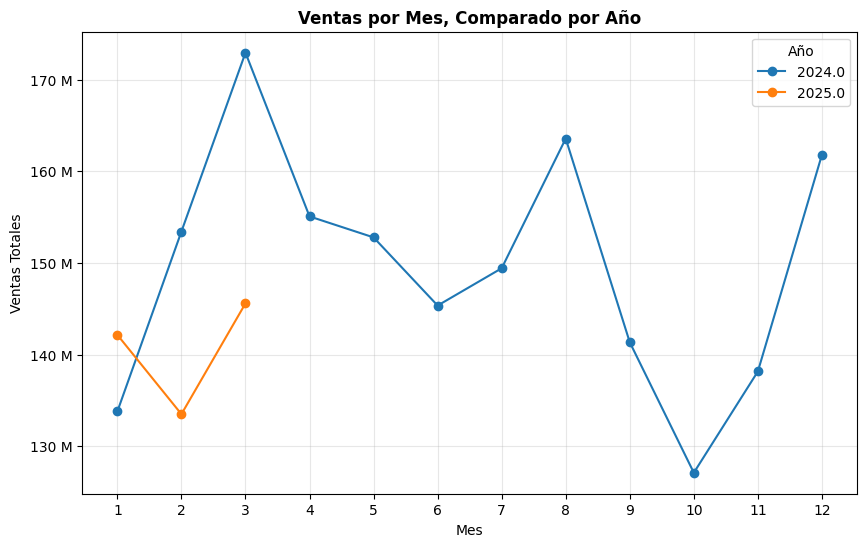

In [219]:
fig, ax = plt.subplots(figsize=(10, 6))

for anio, datos_anio in base.groupby('Anio'):
  # Se agrupan los datos del año y se suman las ventas
  ventas_por_mes = datos_anio.groupby('Mes').agg(Venta_Neta=('Venta_Neta', 'sum'))
  # Grafico de lineas
  ax.plot(ventas_por_mes.index, ventas_por_mes['Venta_Neta'], marker='o', label=str(anio))

# Formateo de titulos
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas Totales')
ax.set_title('Ventas por Mes, Comparado por Año', fontweight="bold")

# Formateo de ejes
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f} M")) # Mostrar el eje en millones

# Formateo de leyenda
ax.legend(title="Año")

# Grilla de fondo
ax.grid(alpha=0.3)

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/ventas_por_mes.png')

plt.show()

### Ventas por Categoria

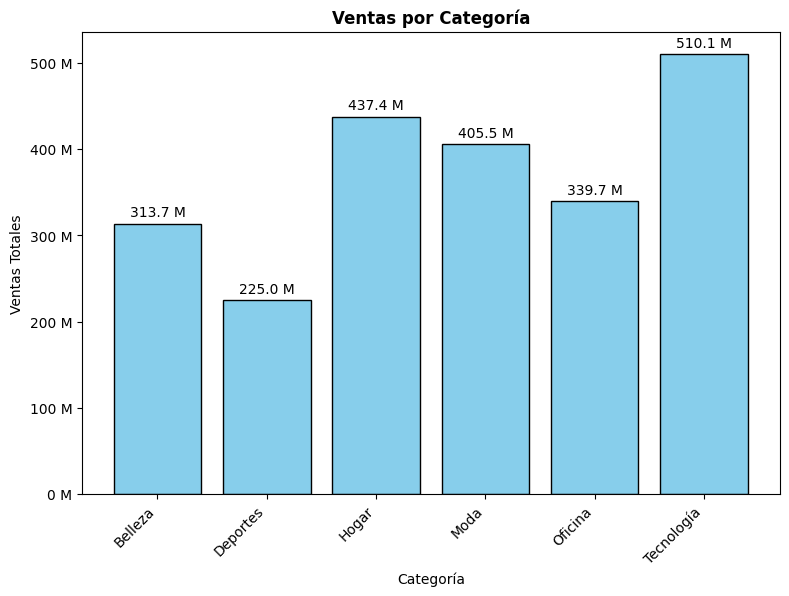

In [220]:
fig, ax = plt.subplots(figsize=(9, 6)) # Tamaño de la figura

# Grafico de barras
ax.bar(ventas_categoria['Categoria'], ventas_categoria['Venta_Neta'], color='skyblue', edgecolor="black")

# Formateo de titulos
ax.set_xlabel('Categoría')
ax.set_ylabel('Ventas Totales')
ax.set_title('Ventas por Categoría', fontweight="bold")

# Formateo de ejes
ax.set_xticks(ventas_categoria['Categoria'])
ax.set_xticklabels(ventas_categoria['Categoria'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f} M")) # Mostrar el eje en millones

# Formateo de etiquetas
ax.bar_label(
    ax.containers[0],
    labels=[f"{v/1e6:.1f} M" for v in ventas_categoria['Venta_Neta']],
    padding=3,
    fontsize=10
)

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/ventas_por_categoria.png')

plt.show()

### Top 10 Productos

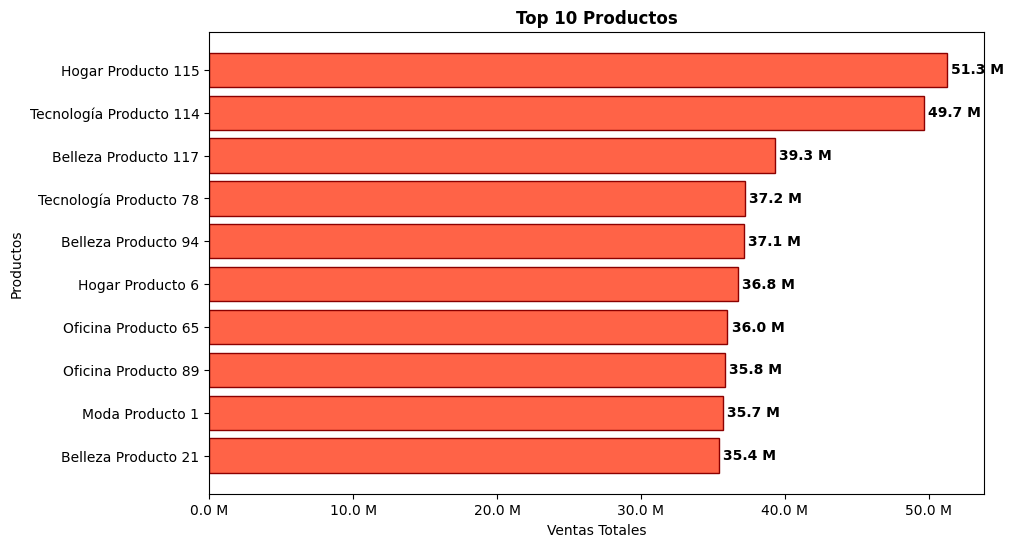

In [221]:
# Ajusta el orden, para mostrar los valore de mayor a menor
top_productos_grafico = top_productos.sort_values('Venta_Neta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_productos_grafico['Producto'], top_productos_grafico['Venta_Neta'], color="tomato", edgecolor="darkred")

# Formateo de titulos
ax.set_title("Top 10 Productos", fontweight="bold")
ax.set_xlabel("Ventas Totales")
ax.set_ylabel("Productos")

# Formateo de ejes
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f} M"))

# Formateo de etiquetas
ax.bar_label(
    ax.containers[0],
    labels=[f"{v/1e6:.1f} M" for v in top_productos_grafico['Venta_Neta']],
    padding=3,
    fontsize=10,
    fontweight='bold'
)

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/top_10_productos.png')

plt.show()

### Top 10 Vendedores

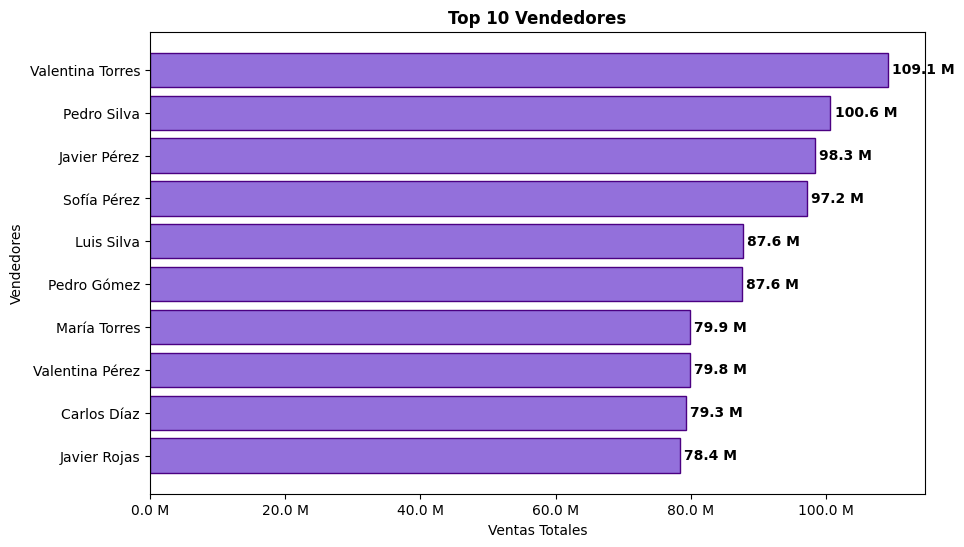

In [222]:
# Ajusta el orden, para mostrar los valore de mayor a menor
top_vendedores_grafico = top_vendedores.sort_values('Venta_Neta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_vendedores_grafico['Vendedor'], top_vendedores_grafico['Venta_Neta'], color="mediumpurple", edgecolor="indigo")

# Formateo de titulos
ax.set_title("Top 10 Vendedores", fontweight="bold")
ax.set_xlabel("Ventas Totales")
ax.set_ylabel("Vendedores")

# Formateo de ejes
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f} M"))

# Formateo de etiquetas
ax.bar_label(
    ax.containers[0],
    labels=[f"{v/1e6:.1f} M" for v in top_vendedores_grafico['Venta_Neta']],
    padding=3,
    fontsize=10,
    fontweight='bold'
)

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/top_10_vendedores.png')

plt.show()

### Ventas por Canal

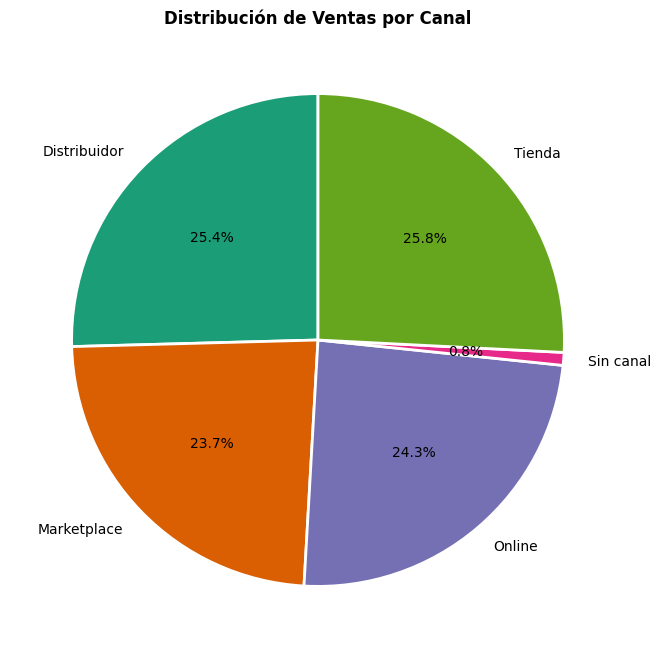

In [223]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = plt.cm.Dark2.colors # Paleta de colores

# Grafico de pastel
ax.pie(
    ventas_canal['Venta_Neta'],
    labels=ventas_canal['Canal'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # Agrega borde blanco entre divisiones
)

# Formateo del titulo
ax.set_title('Distribución de Ventas por Canal', fontweight="bold")

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/ventas_por_canal.png')

plt.show()

### Utilidad por Sucursal

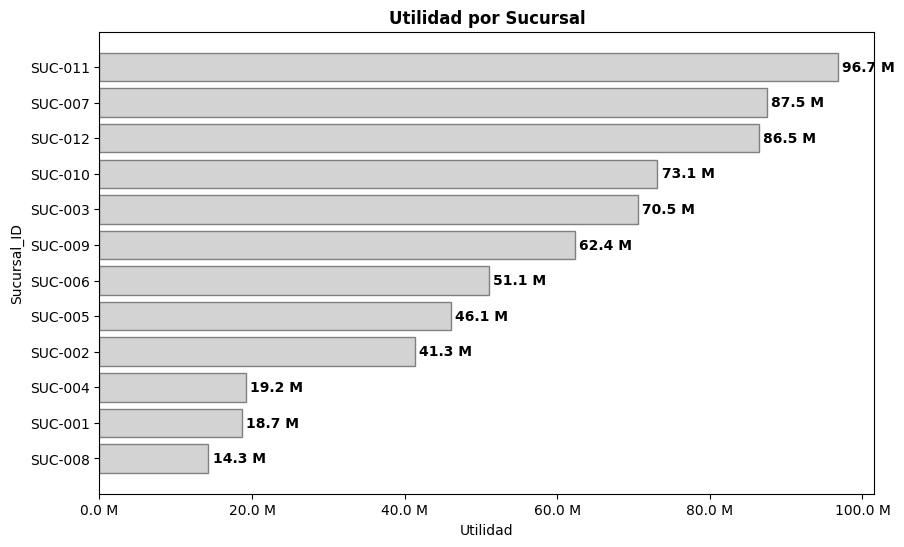

In [224]:
# Ajusta el orden, para mostrar los valore de mayor a menor
utilidad_sucursal_grafico = utilidad_sucursal.sort_values('Utilidad', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(utilidad_sucursal_grafico['SucursalID'], utilidad_sucursal_grafico['Utilidad'], color="lightgray", edgecolor="gray")

# Formateo de titulos
ax.set_title("Utilidad por Sucursal", fontweight="bold")
ax.set_xlabel("Utilidad")
ax.set_ylabel("Sucursal_ID")

# Formateo de ejes
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f} M"))

# Formateo de etiquetas
ax.bar_label(
    ax.containers[0],
    labels=[f"{v/1e6:.1f} M" for v in utilidad_sucursal_grafico['Utilidad']],
    padding=3,
    fontsize=10,
    fontweight='bold'
)

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/utilidad_por_sucursal.png')

plt.show()

### Ventas Reales vs Meta de Ventas

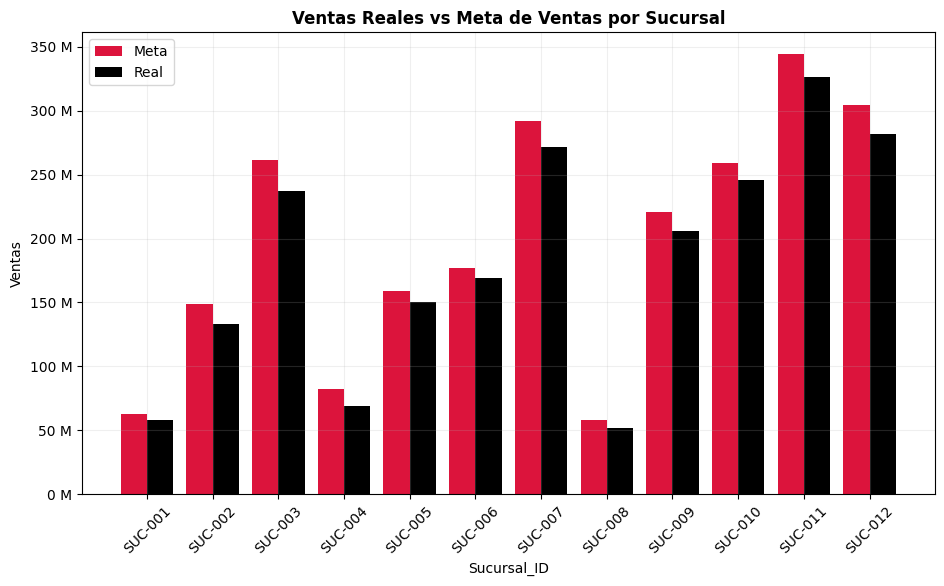

In [225]:
# Se agrupan las ventas por sucursal
resumen_ventas = cumplimiento.groupby('SucursalID', as_index=False).agg(
    Meta_Ventas=('Meta_Ventas', 'sum'),
    Venta_Real=('Venta_Real', 'sum')
)

x = np.arange(len(resumen_ventas))  # Posiciones numéricas: 0, 1, 2, ..., 11
ancho = 0.4  # Ancho de cada barra

fig, ax = plt.subplots(figsize=(11, 6))

# Graficos de barras
ax.bar(x - ancho/2, resumen_ventas['Meta_Ventas'], width=ancho, label='Meta', color='crimson')
ax.bar(x + ancho/2, resumen_ventas['Venta_Real'], width=ancho, label='Real', color='black')

# Formateo de titulos
ax.set_xlabel('Sucursal_ID')
ax.set_ylabel('Ventas')
ax.set_title('Ventas Reales vs Meta de Ventas por Sucursal', fontweight="bold")

# Formateo de ejes
ax.set_xticks(x)
ax.set_xticklabels(resumen_ventas['SucursalID'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f} M")) # Mostrar el eje en millones

# Grilla de fondo
ax.grid(alpha=0.2)

ax.legend(loc="upper left")

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/ventas_reales_vs_meta.png')

plt.show()

### Unidades Reales vs Meta de Unidades

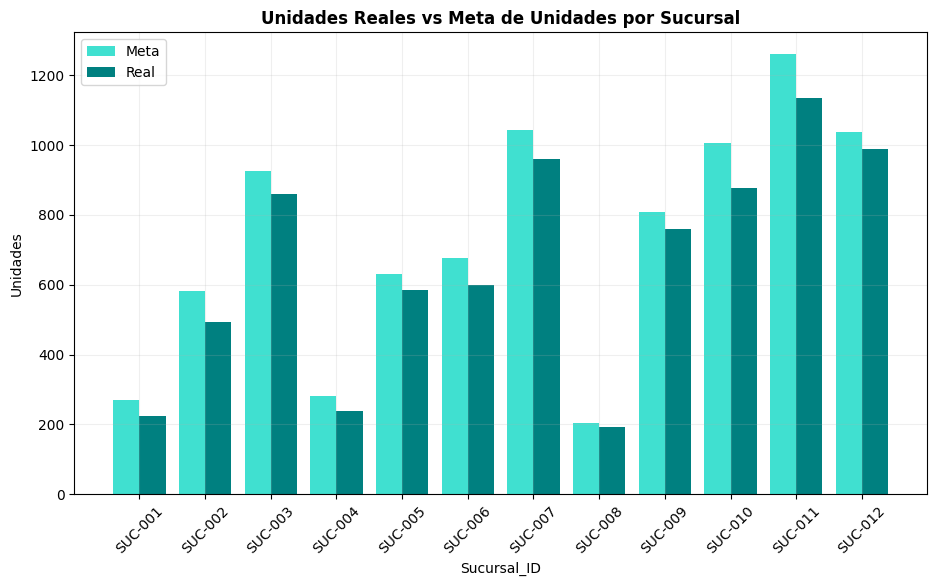

In [226]:
# Se agrupan las unidades por sucursal
resumen_unidades = cumplimiento.groupby('SucursalID', as_index=False).agg(
    Meta_Unidades=('Meta_Unidades', 'sum'),
    Unidades_Real=('Unidades_Real', 'sum')
)

x = np.arange(len(resumen_unidades))  # Posiciones numéricas: 0, 1, 2, ..., 11
ancho = 0.4  # Ancho de cada barra

fig, ax = plt.subplots(figsize=(11, 6))

# Graficos de barras
ax.bar(x - ancho/2, resumen_unidades['Meta_Unidades'], width=ancho, label='Meta', color='turquoise')
ax.bar(x + ancho/2, resumen_unidades['Unidades_Real'], width=ancho, label='Real', color='teal')

# Formateo de titulos
ax.set_xlabel('Sucursal_ID')
ax.set_ylabel('Unidades')
ax.set_title('Unidades Reales vs Meta de Unidades por Sucursal', fontweight="bold")

# Formateo de ejes
ax.set_xticks(x)
ax.set_xticklabels(resumen_unidades['SucursalID'], rotation=45)

# Grilla de fondo
ax.grid(alpha=0.2)

ax.legend(loc="upper left")

# Se guarda el grafico en la carpeta graficos
fig.savefig('/content/sample_data/graficos/unidades_reales_vs_meta.png')

plt.show()

## Exportacion Automatica de Resultados

### Tabla Resumen de KPIs

In [227]:
# Mostrar resultados, tabla de KPIs
kpis = pd.DataFrame({
    'KPI': ['Ventas Totales', 'Utilidad Total', 'Margen General', 'Cantidad Vendida', 'Número de Ventas', 'Ticket Promedio', "Descuento Promedio"],
    'Valor': [ventas_totales, utilidad_total, margen_general, cantidad_total, numero_ventas, ticket_promedio, descuento_promedio]
})

print(kpis)

                  KPI         Valor
0      Ventas Totales  2.238818e+09
1      Utilidad Total  6.721219e+08
2      Margen General  3.002129e-01
3    Cantidad Vendida  8.073000e+03
4    Número de Ventas  1.800000e+03
5     Ticket Promedio  1.243788e+06
6  Descuento Promedio  8.278044e-02


### Archivo Excel Final

In [228]:
# Se crea el Excel y en caja hoja por separado se carga la informacion solicitada
with pd.ExcelWriter('/content/sample_data/reporte_final_analisis_comercial.xlsx', engine='openpyxl') as writer:
    kpis.to_excel(writer, sheet_name='KPIs', index=False)
    base.to_excel(writer, sheet_name='Base_Analitica', index=False)
    ventas_mes.to_excel(writer, sheet_name='Ventas_Mes', index=False)
    ventas_categoria.to_excel(writer, sheet_name='Ventas_Categoria', index=False)
    ventas_pais.to_excel(writer, sheet_name='Ventas_Pais', index=False)
    ventas_canal.to_excel(writer, sheet_name='Ventas_Canal', index=False)
    top_productos.to_excel(writer, sheet_name='Top_Productos', index=False)
    top_vendedores.to_excel(writer, sheet_name='Top_Vendedores', index=False)
    utilidad_sucursal.to_excel(writer, sheet_name='Utilidad_Sucursal', index=False)
    cumplimiento.to_excel(writer, sheet_name='Cumplimiento_Metas', index=False)

In [229]:
# Se verifica el listado de las hojas del archivo
import openpyxl
wb = openpyxl.load_workbook('/content/sample_data/reporte_final_analisis_comercial.xlsx')
print(wb.sheetnames)

['KPIs', 'Base_Analitica', 'Ventas_Mes', 'Ventas_Categoria', 'Ventas_Pais', 'Ventas_Canal', 'Top_Productos', 'Top_Vendedores', 'Utilidad_Sucursal', 'Cumplimiento_Metas']


### Formateo de Informacion de celdas del Archivo Excel Final

#### KPIs

In [230]:
# Recorrer los valores de los KPIs
wb = openpyxl.load_workbook('/content/sample_data/reporte_final_analisis_comercial.xlsx')
hoja_kpis = wb['KPIs']

formato_moneda = '$#,##0'
formato_porcentaje = '0.00%'
formato_numero = '#,##0'

kpis_moneda = ['Ventas Totales', 'Utilidad Total', 'Ticket Promedio']
kpis_porcentaje = ['Margen General', 'Descuento Promedio']
kpis_numero = ['Cantidad Vendida', 'Número de Ventas']

for fila in range(2, hoja_kpis.max_row + 1):
    nombre_kpi = hoja_kpis.cell(row=fila, column=1).value
    celda_valor = hoja_kpis.cell(row=fila, column=2)

    if nombre_kpi in kpis_moneda:
        celda_valor.number_format = formato_moneda
    elif nombre_kpi in kpis_porcentaje:
        celda_valor.number_format = formato_porcentaje
    elif nombre_kpi in kpis_numero:
        celda_valor.number_format = formato_numero

# Se guarda el archivo con los cambios
wb.save('/content/sample_data/reporte_final_analisis_comercial.xlsx')

# Se verifica el formato de cada celda
for fila in range(2, hoja_kpis.max_row + 1):
  celda = hoja_kpis.cell(row=fila, column=2)
  print(fila, celda.value, "-> formato:", celda.number_format)

2 2238817681.06 -> formato: $#,##0
3 672121878.15 -> formato: $#,##0
4 0.3002128685314717 -> formato: 0.00%
5 8073 -> formato: #,##0
6 1800 -> formato: #,##0
7 1243787.600588889 -> formato: $#,##0
8 0.08278044404145313 -> formato: 0.00%


#### Cumplimiento

In [231]:
wb = openpyxl.load_workbook('/content/sample_data/reporte_final_analisis_comercial.xlsx')
hoja_cumplimiento = wb['Cumplimiento_Metas']

formato_moneda = '$#,##0'
formato_porcentaje_directo = '0.00"%"'
formato_numero = '#,##0'

columnas_moneda = [4, 5]       # Meta_Ventas, Venta_Real
columnas_porcentaje = [6, 9]   # Cumplimiento_Ventas_%, Cumplimiento_Unidades_%
columnas_numero = [7, 8]       # Meta_Unidades, Unidades_Real

for fila in range(2, hoja_cumplimiento.max_row + 1):
    for col in columnas_moneda:
        hoja_cumplimiento.cell(row=fila, column=col).number_format = formato_moneda
    for col in columnas_porcentaje:
        hoja_cumplimiento.cell(row=fila, column=col).number_format = formato_porcentaje_directo
    for col in columnas_numero:
        hoja_cumplimiento.cell(row=fila, column=col).number_format = formato_numero

# Se guarda el archivo con los cambios
wb.save('/content/sample_data/reporte_final_analisis_comercial.xlsx')